1. Generate data and save it

In [38]:
# =========================================================
# 10D LQR + DeepONet
# =========================================================
import numpy as np
import torch
from scipy.linalg import solve_continuous_are, eigvals
from torch.utils.data import TensorDataset
import os

# Create save directory
save_dir = '10D'
os.makedirs(save_dir, exist_ok=True)

# =========================================================
# Data generation function
# =========================================================
def generate_case_10_samples(category, num_samples, verbose=False):
    """
    n=10, m=1
    Brunovsky (companion) structure
    category: 'stable' or 'unstable'
    """
    inputs = []
    outputs = []
    n = 10
    m = 1
    
    while len(inputs) < num_samples:
        # ---------- Generate A ----------
        if category == 'stable':
            roots = -np.random.uniform(0.1, 2.0, n)
        elif category == 'unstable':
            n_unstable = np.random.randint(1, 4)
            n_stable = n - n_unstable
            
            unstable_roots = np.random.uniform(0.1, 2.0, n_unstable)
            stable_roots = -np.random.uniform(0.1, 2.0, n_stable)
            
            roots = np.concatenate([unstable_roots, stable_roots])
            np.random.shuffle(roots)
        else:
            raise ValueError(f"Unknown category: {category}")
        
        poly_coeffs = np.poly(roots)
        a = poly_coeffs[::-1][:-1]

        A = np.zeros((n, n))
        A[:-1, 1:] = np.eye(n - 1)
        A[-1, :] = -a

        B = np.zeros((n, 1))
        B[-1, 0] = 1.0

        # Generate Q, R randomly
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)

        try:
            P = solve_continuous_are(A, B, Q, R)
        except:
            continue

        try:
            K = np.linalg.inv(R) @ B.T @ P
            A_cl = A - B @ K
            eigvals_cl = eigvals(A_cl)
            if not np.all(np.real(eigvals_cl) < 0):
                continue
        except:
            continue

        # Verify theorem conditions
        eigvals_Q = eigvals(Q)
        Q_positive_semidefinite = np.all(eigvals_Q >= -1e-10)
        eigvals_R = eigvals(R)
        R_positive_definite = np.all(eigvals_R > 0)
        P_symmetric = np.allclose(P, P.T)
        eigvals_P = eigvals(P)
        P_positive_definite = np.all(eigvals_P > 0)
        riccati_lhs = A.T @ P + P @ A - P @ B @ np.linalg.inv(R) @ B.T @ P + Q
        riccati_error = np.linalg.norm(riccati_lhs, 'fro')
        riccati_satisfied = riccati_error < 1e-8

        if (Q_positive_semidefinite and R_positive_definite and 
            P_symmetric and P_positive_definite and riccati_satisfied):
            
            input_vector = np.concatenate([
                A.flatten(), B.flatten(), Q.flatten(), R.flatten()
            ])  # Total length = 100 + 10 + 100 + 1 = 211

            inputs.append(input_vector)
            outputs.append(P.flatten())

        if verbose and len(inputs) % 500 == 0:
            print(f"Generated samples: {len(inputs)}/{num_samples}")

    return np.array(inputs), np.array(outputs)

# =========================================================
# Generate P grid (for trunk net)
# =========================================================
def generate_P_grid(n=10):
    grid = []
    for i in range(n):
        for j in range(n):
            grid.append([i / (n-1), j / (n-1)])
    return np.array(grid)

# =========================================================
# Generate training & test data
# =========================================================
print("Generating training data...")
train_inputs_stable, train_outputs_stable = generate_case_10_samples('stable', 3000, verbose=False)
train_inputs_unstable, train_outputs_unstable = generate_case_10_samples('unstable', 3000, verbose=False)

train_inputs = np.concatenate([train_inputs_stable, train_inputs_unstable], axis=0)
train_outputs = np.concatenate([train_outputs_stable, train_outputs_unstable], axis=0)

print("Generating test data...")
test_inputs_stable, test_outputs_stable = generate_case_10_samples('stable', 100, verbose=False)
test_inputs_unstable, test_outputs_unstable = generate_case_10_samples('unstable', 100, verbose=False)

test_inputs = np.concatenate([test_inputs_stable, test_inputs_unstable], axis=0)
test_outputs = np.concatenate([test_outputs_stable, test_outputs_unstable], axis=0)

print(f"Total training samples: {len(train_inputs)} (stable: {len(train_inputs_stable)}, unstable: {len(train_inputs_unstable)})")
print(f"Total test samples: {len(test_inputs)} (stable: {len(test_inputs_stable)}, unstable: {len(test_inputs_unstable)})")

# Create labels (1=stable, 0=unstable)
train_labels = np.concatenate([np.ones(len(train_inputs_stable)), np.zeros(len(train_inputs_unstable))])
test_labels = np.concatenate([np.ones(len(test_inputs_stable)), np.zeros(len(test_inputs_unstable))])

# =========================================================
# Normalize P (based on training set)
# =========================================================
P_mean = train_outputs.mean(axis=0, keepdims=True)
P_std = train_outputs.std(axis=0, keepdims=True) + 1e-6

train_outputs_norm = (train_outputs - P_mean) / P_std
test_outputs_norm = (test_outputs - P_mean) / P_std

# Convert to torch tensor (for later training, but only save numpy here)
train_inputs_t = torch.FloatTensor(train_inputs)
train_outputs_norm_t = torch.FloatTensor(train_outputs_norm)
test_inputs_t = torch.FloatTensor(test_inputs)
test_outputs_norm_t = torch.FloatTensor(test_outputs_norm)
train_labels_t = torch.FloatTensor(train_labels)
test_labels_t = torch.FloatTensor(test_labels)

# Generate trunk grid
P_grid = generate_P_grid(10)  # (100,2)

# =========================================================
# Save all data to files
# =========================================================
np.save(os.path.join(save_dir, 'train_inputs.npy'), train_inputs)
np.save(os.path.join(save_dir, 'train_outputs.npy'), train_outputs)
np.save(os.path.join(save_dir, 'train_outputs_norm.npy'), train_outputs_norm)
np.save(os.path.join(save_dir, 'train_labels.npy'), train_labels)

np.save(os.path.join(save_dir, 'test_inputs.npy'), test_inputs)
np.save(os.path.join(save_dir, 'test_outputs.npy'), test_outputs)
np.save(os.path.join(save_dir, 'test_outputs_norm.npy'), test_outputs_norm)
np.save(os.path.join(save_dir, 'test_labels.npy'), test_labels)

np.save(os.path.join(save_dir, 'P_mean.npy'), P_mean)
np.save(os.path.join(save_dir, 'P_std.npy'), P_std)
np.save(os.path.join(save_dir, 'P_grid.npy'), P_grid)

print(f"All data saved to folder '{save_dir}'.")

Generating training data...
Generating test data...
Total training samples: 6000 (stable: 3000, unstable: 3000)
Total test samples: 200 (stable: 100, unstable: 100)
All data saved to folder '10D'.


2. Train the model and save it

In [42]:
# =========================================================
# 10D LQR + DeepONet
# Part 2: Train model and save
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt
import os
import pickle

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load data
save_dir = '10D'
train_inputs = np.load(os.path.join(save_dir, 'train_inputs.npy'))
train_outputs_norm = np.load(os.path.join(save_dir, 'train_outputs_norm.npy'))
train_labels = np.load(os.path.join(save_dir, 'train_labels.npy'))
test_inputs = np.load(os.path.join(save_dir, 'test_inputs.npy'))
test_outputs_norm = np.load(os.path.join(save_dir, 'test_outputs_norm.npy'))
test_labels = np.load(os.path.join(save_dir, 'test_labels.npy'))
P_grid = np.load(os.path.join(save_dir, 'P_grid.npy'))

# Convert to tensor
train_inputs_t = torch.FloatTensor(train_inputs)
train_outputs_norm_t = torch.FloatTensor(train_outputs_norm)
train_labels_t = torch.FloatTensor(train_labels)
test_inputs_t = torch.FloatTensor(test_inputs)
test_outputs_norm_t = torch.FloatTensor(test_outputs_norm)
test_labels_t = torch.FloatTensor(test_labels)

# Create DataLoader
train_dataset = TensorDataset(train_inputs_t, train_outputs_norm_t, train_labels_t)
test_dataset = TensorDataset(test_inputs_t, test_outputs_norm_t, test_labels_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# trunk grid
P_grid_t = torch.FloatTensor(P_grid).to(device)  # (100,2)

# =========================================================
# DeepONet definition
# =========================================================
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim, hidden_dim=64):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        b = self.branch_net(branch_input)          # (B, H)
        Bsz, Np, _ = trunk_input.shape
        t = self.trunk_net(trunk_input.view(-1, 2))
        t = t.view(Bsz, Np, -1)                    # (B, 100, H)
        b = b.unsqueeze(1)                          # (B, 1, H)
        out = self.output_layer(b * t).squeeze(-1)  # (B, 100)
        return out

# Model, optimizer, loss
model = DeepONet(branch_input_dim=train_inputs.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
num_epochs = 1000

train_losses = []
test_losses = []

# =========================================================
# Training loop
# =========================================================
print("Start training...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for xb, yb, _ in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        grid = P_grid_t.unsqueeze(0).repeat(xb.size(0), 1, 1)
        pred = model(xb, grid)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Testing
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for xb, yb, _ in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            grid = P_grid_t.unsqueeze(0).repeat(xb.size(0), 1, 1)
            pred = model(xb, grid)
            test_loss += criterion(pred, yb).item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4e}, "
              f"Test Loss: {avg_test_loss:.4e}")

end_time = time.time()
print(f"Training finished. Total time: {end_time - start_time:.2f} s")

# Save model
torch.save(model.state_dict(), os.path.join(save_dir, 'deeponet_model.pth'))
print(f"Model saved to '{save_dir}' folder.")

Using device: cuda
Start training...
Epoch [20/1000] Train Loss: 5.6238e-01, Test Loss: 2.4510e-01
Epoch [40/1000] Train Loss: 3.1467e-01, Test Loss: 1.8524e-01
Epoch [60/1000] Train Loss: 2.2413e-01, Test Loss: 1.5138e-01
Epoch [80/1000] Train Loss: 1.6764e-01, Test Loss: 9.5238e-02
Epoch [100/1000] Train Loss: 1.4767e-01, Test Loss: 8.3389e-02
Epoch [120/1000] Train Loss: 1.2218e-01, Test Loss: 6.7417e-02
Epoch [140/1000] Train Loss: 1.0682e-01, Test Loss: 9.8421e-02
Epoch [160/1000] Train Loss: 8.9940e-02, Test Loss: 5.8312e-02
Epoch [180/1000] Train Loss: 8.7520e-02, Test Loss: 7.1228e-02
Epoch [200/1000] Train Loss: 6.3570e-02, Test Loss: 4.9431e-02
Epoch [220/1000] Train Loss: 6.1140e-02, Test Loss: 3.9281e-02
Epoch [240/1000] Train Loss: 5.0165e-02, Test Loss: 8.3461e-02
Epoch [260/1000] Train Loss: 4.6851e-02, Test Loss: 5.2192e-02
Epoch [280/1000] Train Loss: 3.7517e-02, Test Loss: 3.5213e-02
Epoch [300/1000] Train Loss: 6.5023e-02, Test Loss: 7.6285e-02
Epoch [320/1000] Train

3. Draw a picture and save it

Using device: cuda
Starting evaluation on test set...
Processed 50/200 samples
Processed 100/200 samples
Processed 150/200 samples
Processed 200/200 samples

STABILITY ANALYSIS RESULTS
Total test samples: 200
True P - Stable samples: 200 (100.00%)
True P - Unstable samples: 0 (0.00%)
Predicted P - Stable samples: 197 (98.50%)
Predicted P - Unstable samples: 3 (1.50%)
----------------------------------------
True P - Total eigenvalues: 2000
True P - Stable eigenvalues: 2000 (100.00%)
Predicted P - Total eigenvalues: 2000
Predicted P - Stable eigenvalues: 1994 (99.70%)


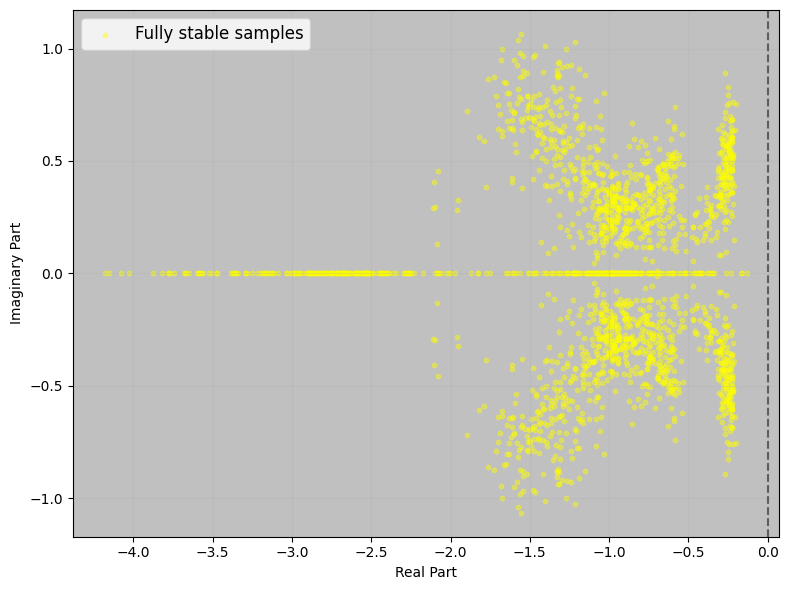

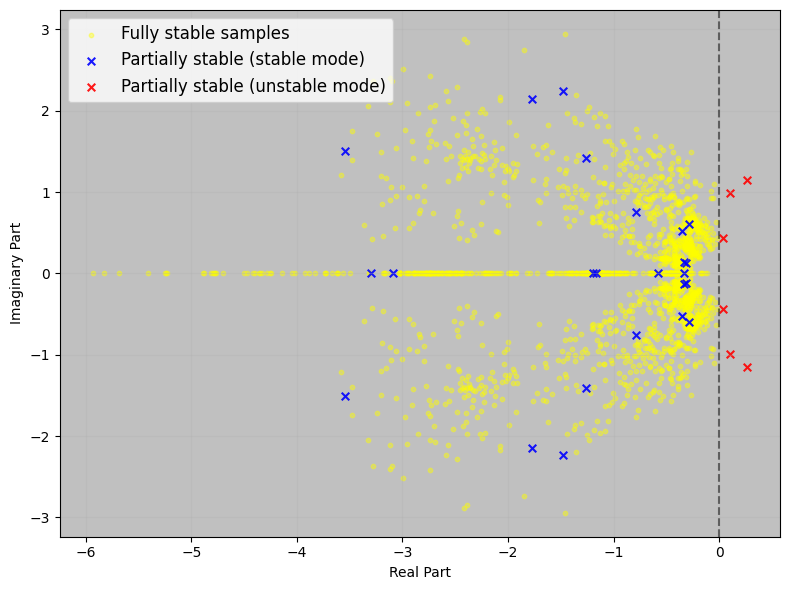

Evaluation completed. Plots saved to '10D' folder.


In [43]:
# =========================================================
# 10D LQR + DeepONet
# Part 3: Evaluate stability and plot eigenvalue distribution
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
import os
import pickle

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load data
save_dir = '10D'
test_inputs = np.load(os.path.join(save_dir, 'test_inputs.npy'))
test_outputs = np.load(os.path.join(save_dir, 'test_outputs.npy'))  # true P
test_labels = np.load(os.path.join(save_dir, 'test_labels.npy'))    # 1=open-loop stable, 0=open-loop unstable
P_mean = np.load(os.path.join(save_dir, 'P_mean.npy'))
P_std = np.load(os.path.join(save_dir, 'P_std.npy'))
P_grid = np.load(os.path.join(save_dir, 'P_grid.npy'))

# Load model
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim, hidden_dim=64):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        b = self.branch_net(branch_input)
        Bsz, Np, _ = trunk_input.shape
        t = self.trunk_net(trunk_input.view(-1, 2))
        t = t.view(Bsz, Np, -1)
        b = b.unsqueeze(1)
        out = self.output_layer(b * t).squeeze(-1)
        return out

model = DeepONet(branch_input_dim=test_inputs.shape[1]).to(device)
model.load_state_dict(torch.load(os.path.join(save_dir, 'deeponet_model.pth'), map_location=device))
model.eval()

# Prepare trunk grid tensor
P_grid_t = torch.FloatTensor(P_grid).to(device).unsqueeze(0)  # (1,100,2)

# =========================================================
# Helper functions
# =========================================================
def extract_system_matrices(input_vector, n=10, m=1):
    A_len = n * n
    B_len = n * m
    Q_len = n * n
    R_len = m * m
    total_len = A_len + B_len + Q_len + R_len
    assert len(input_vector) == total_len

    start = 0
    A_flat = input_vector[start:start + A_len]
    start += A_len
    B_flat = input_vector[start:start + B_len]
    start += B_len
    Q_flat = input_vector[start:start + Q_len]
    start += Q_len
    R_flat = input_vector[start:start + R_len]

    A = A_flat.reshape(n, n)
    B = B_flat.reshape(n, m)
    Q = Q_flat.reshape(n, n)
    R = R_flat.reshape(m, m)
    return A, B, Q, R

def check_open_loop_stability(A):
    eigvals_A = eigvals(A)
    return np.all(np.real(eigvals_A) < 0), eigvals_A

def check_closed_loop_stability(A, B, P_pred, R, n=10, m=1):
    try:
        P_matrix = P_pred.reshape(n, n)
        P_matrix = (P_matrix + P_matrix.T) / 2  # Symmetrize
        if m == 1:
            R_inv = 1.0 / R[0, 0]
            K = R_inv * B.T @ P_matrix
        else:
            R_inv = np.linalg.inv(R)
            K = R_inv @ B.T @ P_matrix
        A_cl = A - B @ K
        eigvals_cl = eigvals(A_cl)
        is_stable = np.all(np.real(eigvals_cl) < 0)
        return is_stable, eigvals_cl, K
    except Exception as e:
        print(f"Error in stability check: {e}")
        return False, None, None

# =========================================================
# Evaluate stability: sample level and eigenvalue level
# =========================================================
n_total = test_inputs.shape[0]
stable_sample_true = []   # Samples stable with true P
stable_sample_pred = []   # Samples stable with predicted P

eigenvalue_data = []      # Store eigenvalue information for plotting

print("Starting evaluation on test set...")
with torch.no_grad():
    for idx in range(n_total):
        x_np = test_inputs[idx]
        y_true_np = test_outputs[idx]  # true P (flattened)
        
        # Predict P
        x_tensor = torch.FloatTensor(x_np).to(device).unsqueeze(0)
        grid = P_grid_t.repeat(x_tensor.size(0), 1, 1)
        pred_norm = model(x_tensor, grid).cpu().numpy().flatten()
        pred_np = pred_norm * P_std.flatten() + P_mean.flatten()

        A, B, Q, R = extract_system_matrices(x_np)
        is_open_loop_stable, _ = check_open_loop_stability(A)  # Determine based on A

        # Closed-loop stability with true P
        stable_true, eigvals_true, _ = check_closed_loop_stability(A, B, y_true_np, R)
        if stable_true is not None:
            stable_sample_true.append(stable_true)
            if eigvals_true is not None:
                for eig in eigvals_true:
                    eigenvalue_data.append({
                        'type': 'True P',
                        'real': np.real(eig),
                        'imag': np.imag(eig),
                        'sample_stable': stable_true
                    })

        # Closed-loop stability with predicted P
        stable_pred, eigvals_pred, _ = check_closed_loop_stability(A, B, pred_np, R)
        if stable_pred is not None:
            stable_sample_pred.append(stable_pred)
            if eigvals_pred is not None:
                for eig in eigvals_pred:
                    eigenvalue_data.append({
                        'type': 'Predicted P',
                        'real': np.real(eig),
                        'imag': np.imag(eig),
                        'sample_stable': stable_pred
                    })

        if (idx+1) % 50 == 0:
            print(f"Processed {idx+1}/{n_total} samples")

# =========================================================
# Statistical results
# =========================================================
print("\n" + "="*60)
print("STABILITY ANALYSIS RESULTS")
print("="*60)

# Sample level
true_stable_count = np.sum(stable_sample_true)
true_unstable_count = len(stable_sample_true) - true_stable_count
pred_stable_count = np.sum(stable_sample_pred)
pred_unstable_count = len(stable_sample_pred) - pred_stable_count

print(f"Total test samples: {n_total}")
print(f"True P - Stable samples: {true_stable_count} ({true_stable_count/len(stable_sample_true):.2%})")
print(f"True P - Unstable samples: {true_unstable_count} ({true_unstable_count/len(stable_sample_true):.2%})")
print(f"Predicted P - Stable samples: {pred_stable_count} ({pred_stable_count/len(stable_sample_pred):.2%})")
print(f"Predicted P - Unstable samples: {pred_unstable_count} ({pred_unstable_count/len(stable_sample_pred):.2%})")

# Eigenvalue level
true_eigs = [d for d in eigenvalue_data if d['type'] == 'True P']
pred_eigs = [d for d in eigenvalue_data if d['type'] == 'Predicted P']

true_stable_eigs = [d for d in true_eigs if d['real'] < 0]
pred_stable_eigs = [d for d in pred_eigs if d['real'] < 0]

print("-"*40)
print(f"True P - Total eigenvalues: {len(true_eigs)}")
print(f"True P - Stable eigenvalues: {len(true_stable_eigs)} ({len(true_stable_eigs)/len(true_eigs):.2%})")
print(f"Predicted P - Total eigenvalues: {len(pred_eigs)}")
print(f"Predicted P - Stable eigenvalues: {len(pred_stable_eigs)} ({len(pred_stable_eigs)/len(pred_eigs):.2%})")
print("="*60)

# =========================================================
# Plot eigenvalue distribution (True P vs Predicted P)
# =========================================================
# Figure 1: True P
plt.figure(figsize=(8, 6))
plt.gca().set_facecolor('silver')

true_data = [d for d in eigenvalue_data if d['type'] == 'True P']
fully_stable_true = [d for d in true_data if d['sample_stable']]
partially_stable_stable_true = [d for d in true_data if not d['sample_stable'] and d['real'] < 0]
partially_stable_unstable_true = [d for d in true_data if not d['sample_stable'] and d['real'] >= 0]

if fully_stable_true:
    plt.scatter([d['real'] for d in fully_stable_true],
                [d['imag'] for d in fully_stable_true],
                c='yellow', marker='o', label='Fully stable samples', alpha=0.4, s=10)
if partially_stable_stable_true:
    plt.scatter([d['real'] for d in partially_stable_stable_true],
                [d['imag'] for d in partially_stable_stable_true],
                c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=30)
if partially_stable_unstable_true:
    plt.scatter([d['real'] for d in partially_stable_unstable_true],
                [d['imag'] for d in partially_stable_unstable_true],
                c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=30)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'eigenvalue_distribution_true.png'), dpi=300)
plt.show()

# Figure 2: Predicted P
plt.figure(figsize=(8, 6))
plt.gca().set_facecolor('silver')

pred_data = [d for d in eigenvalue_data if d['type'] == 'Predicted P']
fully_stable_pred = [d for d in pred_data if d['sample_stable']]
partially_stable_stable_pred = [d for d in pred_data if not d['sample_stable'] and d['real'] < 0]
partially_stable_unstable_pred = [d for d in pred_data if not d['sample_stable'] and d['real'] >= 0]

if fully_stable_pred:
    plt.scatter([d['real'] for d in fully_stable_pred],
                [d['imag'] for d in fully_stable_pred],
                c='yellow', marker='o', label='Fully stable samples', alpha=0.4, s=10)
if partially_stable_stable_pred:
    plt.scatter([d['real'] for d in partially_stable_stable_pred],
                [d['imag'] for d in partially_stable_stable_pred],
                c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=30)
if partially_stable_unstable_pred:
    plt.scatter([d['real'] for d in partially_stable_unstable_pred],
                [d['imag'] for d in partially_stable_unstable_pred],
                c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=30)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'eigenvalue_distribution_pred.png'), dpi=300)
plt.show()

# Save eigenvalue data for further analysis
with open(os.path.join(save_dir, 'eigenvalue_data.pkl'), 'wb') as f:
    pickle.dump(eigenvalue_data, f)

print(f"Evaluation completed. Plots saved to '{save_dir}' folder.")

In [44]:
# =========================================================
# Output unstable eigenvalue coordinates from predicted P (real >= 0)
# =========================================================
print("\n" + "="*60)
print("Unstable eigenvalues from predicted P (real >= 0):")
print("="*60)
unstable_pred_eigs = [d for d in eigenvalue_data if d['type'] == 'Predicted P' and d['real'] >= 0]
if unstable_pred_eigs:
    for i, eig in enumerate(unstable_pred_eigs):
        print(f"Point {i+1}: real = {eig['real']:.6f}, imag = {eig['imag']:.6f}")
    print(f"Total number of unstable eigenvalues: {len(unstable_pred_eigs)}")
else:
    print("No unstable eigenvalues found in predicted P.")
print("="*60)


# =========================================================
# New section: Analyze the relationship between E and delta in unstable predictions
# =========================================================
print("\n" + "="*60)
print("ANALYSIS OF UNSTABLE PREDICTIONS (E vs delta)")
print("="*60)

# Reload necessary data (or reuse existing variables, but reload for clarity)
test_inputs = np.load(os.path.join(save_dir, 'test_inputs.npy'))
test_outputs = np.load(os.path.join(save_dir, 'test_outputs.npy'))   # true P*
test_labels = np.load(os.path.join(save_dir, 'test_labels.npy'))     # open-loop stability label
P_mean = np.load(os.path.join(save_dir, 'P_mean.npy'))
P_std = np.load(os.path.join(save_dir, 'P_std.npy'))

# Ensure model is in eval mode
model.eval()

# Store information of unstable samples
unstable_samples_info = []

with torch.no_grad():
    for idx in range(len(test_inputs)):
        x_np = test_inputs[idx]
        y_true_np = test_outputs[idx]  # true P* (flattened)
        
        # Predict P_hat
        x_tensor = torch.FloatTensor(x_np).to(device).unsqueeze(0)
        grid = P_grid_t.repeat(x_tensor.size(0), 1, 1)
        pred_norm = model(x_tensor, grid).cpu().numpy().flatten()
        pred_np = pred_norm * P_std.flatten() + P_mean.flatten()

        A, B, Q, R = extract_system_matrices(x_np)

        # Check closed-loop stability with predicted P
        stable_pred, _, _ = check_closed_loop_stability(A, B, pred_np, R)
        
        if not stable_pred:  # only process samples that are predicted unstable
            # Compute error E = ||hatP - P*||_2
            P_star = y_true_np.reshape(10, 10)
            P_hat = pred_np.reshape(10, 10)
            E = np.linalg.norm(P_hat - P_star, ord=2)

            # Compute optimal gain K*
            if R.shape[0] == 1:  # m=1
                R_inv = 1.0 / R[0, 0]
                K_star = R_inv * (B.T @ P_star)  # shape (1,10)
            else:
                R_inv = np.linalg.inv(R)
                K_star = R_inv @ B.T @ P_star

            # Compute M = Q + (K*)^T R K*
            M = Q + K_star.T @ R @ K_star
            # Minimum eigenvalue (M is symmetric)
            eigvals_M = np.linalg.eigvalsh(M)
            lambda_min_M = eigvals_M.min()

            # Compute various norms
            B_norm = np.linalg.norm(B, ord=2)
            R_inv_norm = np.linalg.norm(np.linalg.inv(R), ord=2) if R.shape[0] > 1 else 1.0 / R[0,0]
            P_star_norm = np.linalg.norm(P_star, ord=2)

            # Compute delta
            denominator = 2 * (B_norm**2) * R_inv_norm * P_star_norm
            if denominator > 0:
                delta = lambda_min_M / denominator
            else:
                delta = np.inf  # avoid division by zero, though it should not happen in theory

            unstable_samples_info.append({
                'index': idx,
                'E': E,
                'delta': delta,
                'E_lt_delta': E < delta,
                'lambda_min_M': lambda_min_M,
                'B_norm': B_norm,
                'R_inv_norm': R_inv_norm,
                'P_star_norm': P_star_norm
            })

# Statistical results
n_unstable = len(unstable_samples_info)
n_lt_delta = sum([info['E_lt_delta'] for info in unstable_samples_info])
n_ge_delta = n_unstable - n_lt_delta

print(f"\nTotal number of predicted unstable samples: {n_unstable}")
if n_unstable > 0:
    print(f"Samples satisfying E < delta: {n_lt_delta} ({n_lt_delta/n_unstable:.2%})")
    print(f"Samples satisfying E >= delta: {n_ge_delta} ({n_ge_delta/n_unstable:.2%})")
print("="*60)


Unstable eigenvalues from predicted P (real >= 0):
Point 1: real = 0.266422, imag = 1.150879
Point 2: real = 0.266422, imag = -1.150879
Point 3: real = 0.105703, imag = 0.988786
Point 4: real = 0.105703, imag = -0.988786
Point 5: real = 0.038628, imag = 0.439539
Point 6: real = 0.038628, imag = -0.439539
Total number of unstable eigenvalues: 6

ANALYSIS OF UNSTABLE PREDICTIONS (E vs delta)

Total number of predicted unstable samples: 3
Samples satisfying E < delta: 0 (0.00%)
Samples satisfying E >= delta: 3 (100.00%)


4. Comparison of Speeds between DeepONet and CARE 

Using device: cuda
Model loaded successfully.

Generating 500 random test samples (n=10, m=1)...
Dataset generation completed.

1. Testing CARE sequential solving...
  CARE completed 100/500
  CARE completed 200/500
  CARE completed 300/500
  CARE completed 400/500
  CARE completed 500/500
  CARE average time: 0.8737 ms/sample, std: 0.3511 ms

2. Testing DeepONet single-sample inference (loop)...
  Single-sample inference completed 100/500
  Single-sample inference completed 200/500
  Single-sample inference completed 300/500
  Single-sample inference completed 400/500
  Single-sample inference completed 500/500
  DeepONet single-sample average time: 0.2137 ms/sample, std: 0.0863 ms

3. Testing DeepONet batch inference...
  Total batch inference time: 0.7473 ms
  Average batch inference time: 0.0015 ms/sample

Speed comparison summary (n=10, 500 samples)
------------------------------------------------------------
CARE solving               : average 0.8737 ms/sample
DeepONet single-sa

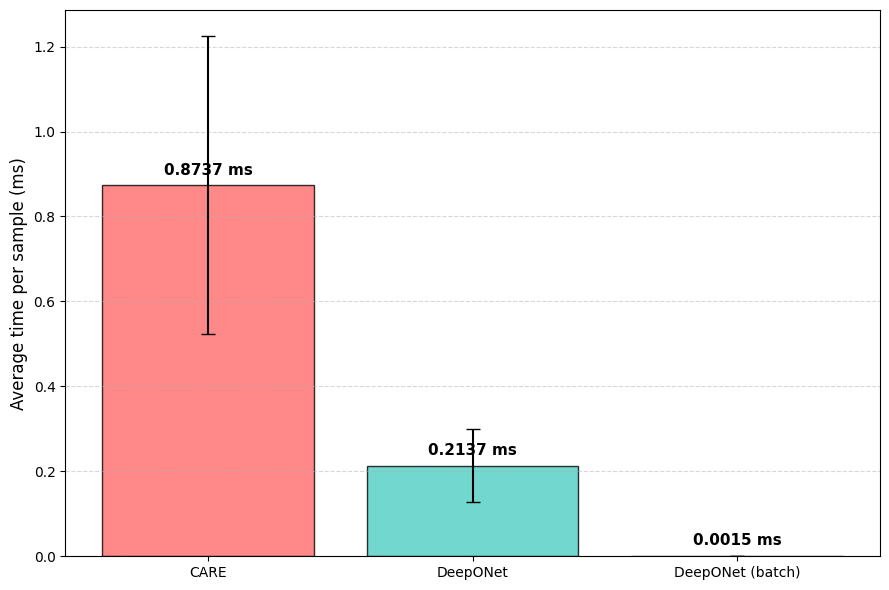


Speed comparison plot saved to 10D\speed_comparison_10d.png


In [5]:
import torch
import numpy as np
import scipy.linalg
import time
import os
import matplotlib.pyplot as plt

# -------------------- Device setup --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------- Define DeepONet model structure (must match training) --------------------
class DeepONet(torch.nn.Module):
    def __init__(self, branch_input_dim=211, hidden_dim=64):
        super().__init__()
        self.branch_net = torch.nn.Sequential(
            torch.nn.Linear(branch_input_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, hidden_dim)
        )
        self.trunk_net = torch.nn.Sequential(
            torch.nn.Linear(2, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, hidden_dim)
        )
        self.output_layer = torch.nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        b = self.branch_net(branch_input)                 # (B, H)
        Bsz, Np, _ = trunk_input.shape
        t = self.trunk_net(trunk_input.view(-1, 2))
        t = t.view(Bsz, Np, -1)                            # (B, Np, H)
        b = b.unsqueeze(1)                                  # (B, 1, H)
        out = self.output_layer(b * t).squeeze(-1)          # (B, Np)
        return out

# -------------------- Load model and position grid --------------------
save_dir = "10D"                     # Folder where model and data are stored
model_path = os.path.join(save_dir, "deeponet_model.pth")
grid_path = os.path.join(save_dir, "P_grid.npy")

model = DeepONet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully.")

P_grid = np.load(grid_path)          # shape (100, 2)
grid_tensor = torch.FloatTensor(P_grid).to(device)  # (100, 2)
num_points = P_grid.shape[0]         # = 100

# -------------------- Function to generate a single valid test system (only CARE solvable) --------------------
def generate_random_system_10d():
    """Generate a random system with n=10, m=1, ensuring CARE is solvable. Returns input vector (211,) and (A, B, Q, R)."""
    n = 10
    m = 1
    while True:
        # Randomly choose open-loop stable or unstable (proportion arbitrary, only for generating valid systems)
        if np.random.rand() > 0.5:
            # stable
            roots = -np.random.uniform(0.1, 2.0, n)
        else:
            # unstable (1 to 3 unstable poles)
            n_unstable = np.random.randint(1, 4)
            n_stable = n - n_unstable
            unstable_roots = np.random.uniform(0.1, 2.0, n_unstable)
            stable_roots = -np.random.uniform(0.1, 2.0, n_stable)
            roots = np.concatenate([unstable_roots, stable_roots])
            np.random.shuffle(roots)

        # Construct A in Brunovsky form
        poly_coeffs = np.poly(roots)
        a = poly_coeffs[::-1][:-1]          # coefficients of characteristic polynomial (excluding highest order)
        A = np.zeros((n, n))
        A[:-1, 1:] = np.eye(n - 1)
        A[-1, :] = -a

        B = np.zeros((n, 1))
        B[-1, 0] = 1.0

        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)   # scalar

        # Verify that CARE is solvable (using try)
        try:
            scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue

        # Build input vector (consistent with training data: concatenate flattened A, B, Q, R)
        input_vector = np.concatenate([A.flatten(), B.flatten(), Q.flatten(), R.flatten()])
        return input_vector, A, B, Q, R

def generate_dataset(num_samples):
    """Generate num_samples valid samples, return input array and list of (A, B, Q, R)."""
    inputs = []
    systems = []
    for _ in range(num_samples):
        vec, A, B, Q, R = generate_random_system_10d()
        inputs.append(vec)
        systems.append((A, B, Q, R))
    return np.array(inputs), systems

# -------------------- Prepare test dataset --------------------
num_samples = 500                     # Adjustable
print(f"\nGenerating {num_samples} random test samples (n=10, m=1)...")
branch_inputs, systems = generate_dataset(num_samples)
print("Dataset generation completed.")

# -------------------- 1. CARE sequential solving --------------------
print("\n1. Testing CARE sequential solving...")
care_times = []
for i, (A, B, Q, R) in enumerate(systems):
    start = time.perf_counter()
    P = scipy.linalg.solve_continuous_are(A, B, Q, R)
    care_times.append(time.perf_counter() - start)
    if (i+1) % 100 == 0:
        print(f"  CARE completed {i+1}/{num_samples}")

avg_care = np.mean(care_times) * 1000   # milliseconds
std_care = np.std(care_times) * 1000
print(f"  CARE average time: {avg_care:.4f} ms/sample, std: {std_care:.4f} ms")

# -------------------- 2. DeepONet single-sample inference --------------------
print("\n2. Testing DeepONet single-sample inference (loop)...")
deeponet_single_times = []
for i in range(num_samples):
    branch_input = torch.FloatTensor(branch_inputs[i]).unsqueeze(0).to(device)  # (1, 211)
    grid_batch = grid_tensor.unsqueeze(0)                                       # (1, 100, 2)
    start = time.perf_counter()
    with torch.no_grad():
        pred = model(branch_input, grid_batch)
    deeponet_single_times.append(time.perf_counter() - start)
    if (i+1) % 100 == 0:
        print(f"  Single-sample inference completed {i+1}/{num_samples}")

avg_single = np.mean(deeponet_single_times) * 1000
std_single = np.std(deeponet_single_times) * 1000
print(f"  DeepONet single-sample average time: {avg_single:.4f} ms/sample, std: {std_single:.4f} ms")

# -------------------- 3. DeepONet batch inference --------------------
print("\n3. Testing DeepONet batch inference...")
# Construct batch input
branch_tensor = torch.FloatTensor(branch_inputs).to(device)                     # (num_samples, 211)
grid_batch = grid_tensor.unsqueeze(0).repeat(num_samples, 1, 1)              # (num_samples, 100, 2)

# Warm-up (optional)
with torch.no_grad():
    _ = model(branch_tensor[:min(10, num_samples)], grid_batch[:min(10, num_samples)])

# Timing
if device.type == 'cuda':
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    pred_batch = model(branch_tensor, grid_batch)
if device.type == 'cuda':
    torch.cuda.synchronize()
batch_time = time.perf_counter() - start

avg_batch = batch_time / num_samples * 1000   # average milliseconds per sample
print(f"  Total batch inference time: {batch_time*1000:.4f} ms")
print(f"  Average batch inference time: {avg_batch:.4f} ms/sample")

# -------------------- Summary --------------------
print("\n" + "="*60)
print(f"Speed comparison summary (n=10, {num_samples} samples)")
print("-" * 60)
print(f"CARE solving               : average {avg_care:.4f} ms/sample")
print(f"DeepONet single-sample      : average {avg_single:.4f} ms/sample")
print(f"DeepONet batch              : average {avg_batch:.4f} ms/sample")
print("-" * 60)
print(f"Batch vs CARE               : {avg_care/avg_batch:.2f} times")
print(f"Batch vs single-sample      : {avg_single/avg_batch:.2f} times")
print("="*60)

# -------------------- Plot --------------------
methods = ['CARE', 'DeepONet', 'DeepONet (batch)']
avg_times = [avg_care, avg_single, avg_batch]
std_times = [std_care, std_single, 0]   # batch has no standard deviation

plt.figure(figsize=(9, 6))
bars = plt.bar(methods, avg_times, yerr=std_times, capsize=5,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')

# Annotate values above bars
for bar, avg in zip(bars, avg_times):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02*max(avg_times),
             f'{avg:.4f} ms', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Average time per sample (ms)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'speed_comparison_10d.png'), dpi=300)
plt.show()

print(f"\nSpeed comparison plot saved to {os.path.join(save_dir, 'speed_comparison_10d.png')}")

5. Draw the picture

Loaded 4000 eigenvalue records


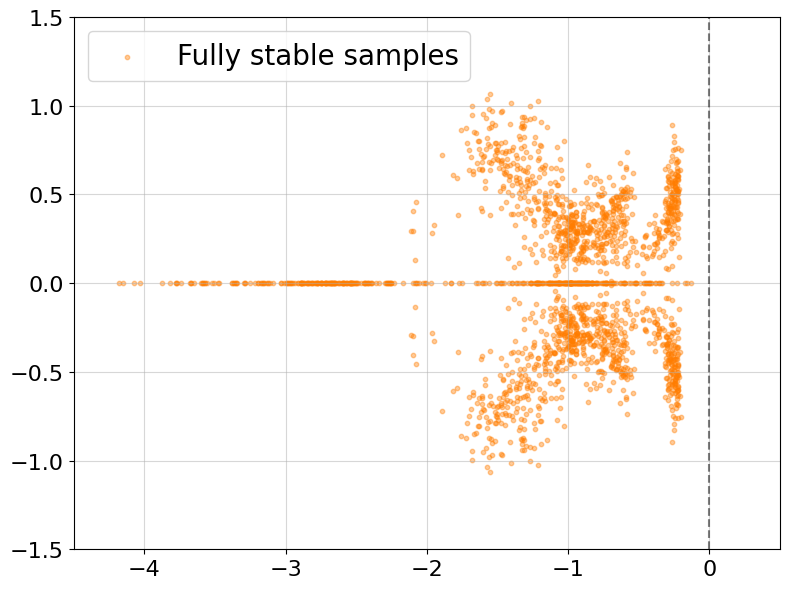

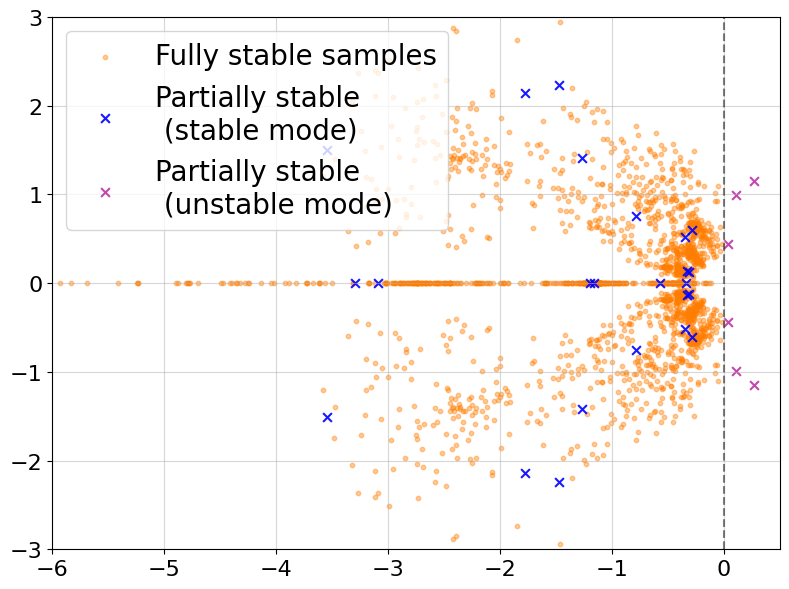

Plotting completed, images saved to 10D


In [6]:
import pickle
import matplotlib.pyplot as plt
import os

# =========================================================
# Load eigenvalue data
# =========================================================
save_dir = '10D'
pkl_path = os.path.join(save_dir, 'eigenvalue_data.pkl')

with open(pkl_path, 'rb') as f:
    eigenvalue_data = pickle.load(f)

print(f"Loaded {len(eigenvalue_data)} eigenvalue records")

# =========================================================
# Helper classification function (consistent with original code)
# =========================================================
def classify_eigenvalues(data_list):
    """
    Classify eigenvalues into three categories:
    - fully_stable: all eigenvalues from fully stable samples (sample_stable == True)
    - partially_stable_stable: eigenvalues with real part < 0 from unstable samples
    - partially_stable_unstable: eigenvalues with real part >= 0 from unstable samples
    """
    fully_stable = []
    partially_stable_stable = []
    partially_stable_unstable = []
    
    for d in data_list:
        if d['sample_stable']:  # sample fully stable
            fully_stable.append(d)
        else:                   # sample not fully stable
            if d['real'] < 0:
                partially_stable_stable.append(d)
            else:
                partially_stable_unstable.append(d)
    return fully_stable, partially_stable_stable, partially_stable_unstable

# =========================================================
# Figure 1: Eigenvalue distribution for true P
# =========================================================
true_data = [d for d in eigenvalue_data if d['type'] == 'True P']
fully_true, stable_true, unstable_true = classify_eigenvalues(true_data)

plt.figure(figsize=(8, 6))
# Set background color
#plt.gca().set_facecolor([0.92,0.92,0.92])

if fully_true:
    plt.scatter([d['real'] for d in fully_true],
                [d['imag'] for d in fully_true],
                color=[1,0.49,0], marker='o', label='Fully stable samples', alpha=0.4, s=10)
if stable_true:
    plt.scatter([d['real'] for d in stable_true],
                [d['imag'] for d in stable_true],
                color='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=40)
if unstable_true:
    plt.scatter([d['real'] for d in unstable_true],
                [d['imag'] for d in unstable_true],
                color=[0.74,0.2,0.64], marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=40)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
#plt.xlabel('Real Part')
#plt.ylabel('Imaginary Part')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc='best', fontsize=20)
plt.grid(True, alpha=0.5)
plt.xlim(-4.5, 0.5)
plt.ylim(-1.5, 1.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'True_P_10D.png'), dpi=300)
plt.show()

# =========================================================
# Figure 2: Eigenvalue distribution for predicted P
# =========================================================
pred_data = [d for d in eigenvalue_data if d['type'] == 'Predicted P']
fully_pred, stable_pred, unstable_pred = classify_eigenvalues(pred_data)

plt.figure(figsize=(8, 6))
#plt.gca().set_facecolor([0.92,0.92,0.92])

if fully_pred:
    plt.scatter([d['real'] for d in fully_pred],
                [d['imag'] for d in fully_pred],
                color=[1,0.49,0], marker='o', label='Fully stable samples', alpha=0.4, s=10)
if stable_pred:
    plt.scatter([d['real'] for d in stable_pred],
                [d['imag'] for d in stable_pred],
                color='blue', marker='x', label='Partially stable \n (stable mode)', alpha=0.9, s=40)
if unstable_pred:
    plt.scatter([d['real'] for d in unstable_pred],
                [d['imag'] for d in unstable_pred],
                color=[0.74,0.2,0.64], marker='x', label='Partially stable \n (unstable mode)', alpha=0.9, s=40)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.xlabel('Real Part')
#plt.ylabel('Imaginary Part')
plt.legend(loc='best', fontsize=20)
plt.grid(True, alpha=0.5)
plt.xlim(-6, 0.5)
plt.ylim(-3, 3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'Predict_P_10D.png'), dpi=300)
plt.show()

print("Plotting completed, images saved to", save_dir)